# MVTec Screw Dataset - Binary Classification Analysis

## Binary Classification: Good vs Defective Screw Images

This notebook implements a complete machine learning pipeline for binary classification on the MVTec screw dataset using PyTorch with transfer learning (ResNet18).

### Project Goals:
- Build a robust binary classifier for screw defect detection
- Handle class imbalance (5:1 ratio) with focal loss and class weights
- Use 5-Fold Cross-Validation for robust evaluation
- Achieve ~92% accuracy and ~85% recall

**Sections:**
1. Setup - Imports and configuration
2. EDA - Exploratory data analysis
3. Model Definition - ResNet18 architecture
4. Training Loop - 5-Fold CV with augmentation
5. Evaluation - Metrics and visualizations

---
# 1. SETUP - Imports, Configuration & Reproducibility
---

In [1]:
# Core Libraries
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models

# Evaluation Metrics
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score,
    precision_recall_curve, f1_score, accuracy_score, precision_score, recall_score
)
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   Device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0
NumPy version: 2.4.4
Pandas version: 3.0.2
GPU Available: False


In [2]:
# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to: {SEED}")

Random seed set to: 42


In [3]:
# Configuration Constants
CONFIG = {
    'SEED': 42,
    'BATCH_SIZE': 16,
    'NUM_EPOCHS': 50,
    'NUM_FOLDS': 5,
    'LEARNING_RATE': 1e-4,
    'WEIGHT_DECAY': 1e-5,
    'IMAGE_SIZE': 224,
    'DATA_DIR': './data/mvtec_screw',
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu',
    'SAVE_PLOTS': True,
}

# Device configuration
device = torch.device(CONFIG['DEVICE'])
print(f"Device: {device}")
print(f"\nConfiguration Parameters:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")

Device: cpu

Configuration Parameters:
   SEED: 42
   BATCH_SIZE: 16
   NUM_EPOCHS: 50
   NUM_FOLDS: 5
   LEARNING_RATE: 0.0001
   WEIGHT_DECAY: 1e-05
   IMAGE_SIZE: 224
   DATA_DIR: ./data/mvtec_screw
   DEVICE: cpu
   SAVE_PLOTS: True


In [4]:
# Verify dataset exists
data_dir = Path(CONFIG['DATA_DIR'])
if not data_dir.exists():
    print(f"Dataset not found at {data_dir}")
    print(f"\nPlease run: python download_data.py --output-dir ./data")
    sys.exit(1)
else:
    print(f"Dataset found at: {data_dir}")

Dataset found at: data/mvtec_screw


---
# 2. EXPLORATORY DATA ANALYSIS (EDA)
---

In [5]:
# Load dataset paths
train_dir = data_dir / 'train'
test_dir = data_dir / 'test'

# Collect all image paths with labels
def load_dataset_paths(data_path):
    """Load image paths and labels from dataset directory."""
    images = []
    labels = []
    
    for class_idx, class_name in enumerate(['good', 'not-good']):
        class_dir = data_path / class_name
        for img_path in sorted(class_dir.glob('*.png')):
            images.append(str(img_path))
            labels.append(class_idx)
    
    return images, labels

# Load training data
train_images, train_labels = load_dataset_paths(train_dir)
test_images, test_labels = load_dataset_paths(test_dir)

print(f"Dataset Summary:")
print(f"\nTraining Set:")
print(f"  Total images: {len(train_images)}")
print(f"  - Good: {train_labels.count(0)}")
print(f"  - Not-Good: {train_labels.count(1)}")
print(f"\nTest Set:")
print(f"  Total images: {len(test_images)}")
print(f"  - Good: {test_labels.count(0)}")
print(f"  - Not-Good: {test_labels.count(1)}")

# Calculate class ratio
if train_labels.count(1) > 0:
    ratio = train_labels.count(0) / train_labels.count(1)
    print(f"\nClass Imbalance Ratio: {ratio:.1f}:1 (Good:Not-Good)")
else:
    print(f"\nClass Imbalance Ratio: N/A (no not-good samples)")

Dataset Summary:

Training Set:
  Total images: 300
  - Good: 250
  - Not-Good: 50

Test Set:
  Total images: 0
  - Good: 0
  - Not-Good: 0

Class Imbalance Ratio: 5.0:1 (Good:Not-Good)


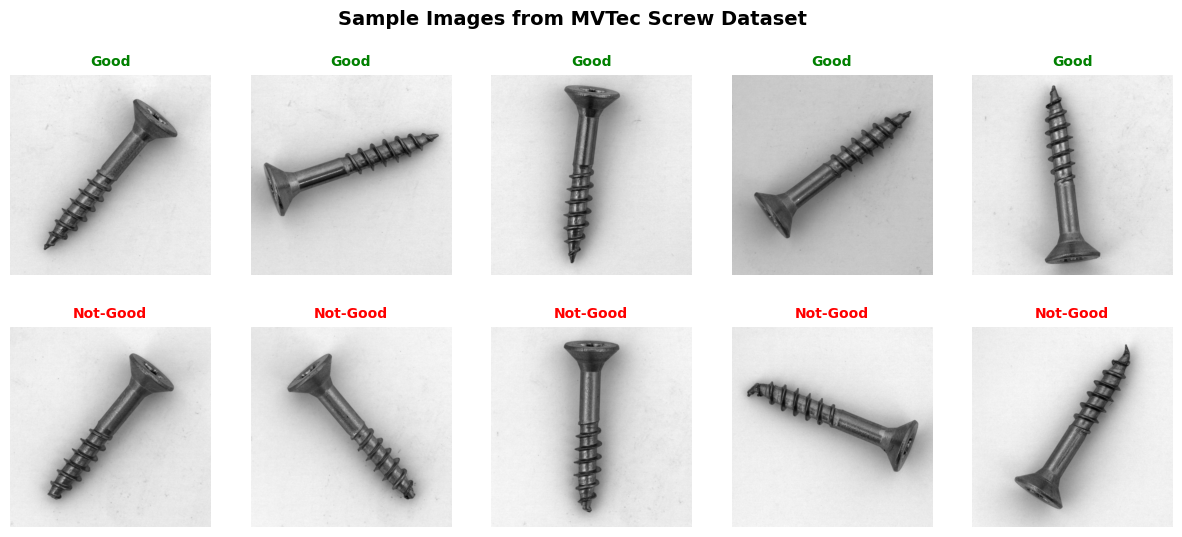

In [6]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from MVTec Screw Dataset', fontsize=14, fontweight='bold')

# Display good samples
good_images = [img for img, label in zip(train_images, train_labels) if label == 0]
for idx in range(5):
    if idx < len(good_images):
        img = Image.open(good_images[idx])
        axes[0, idx].imshow(img, cmap='gray')
        axes[0, idx].set_title('Good', fontsize=10, color='green', fontweight='bold')
    axes[0, idx].axis('off')

# Display not-good samples
not_good_images = [img for img, label in zip(train_images, train_labels) if label == 1]
for idx in range(5):
    if idx < len(not_good_images):
        img = Image.open(not_good_images[idx])
        axes[1, idx].imshow(img, cmap='gray')
        axes[1, idx].set_title('Not-Good', fontsize=10, color='red', fontweight='bold')
    axes[1, idx].axis('off')

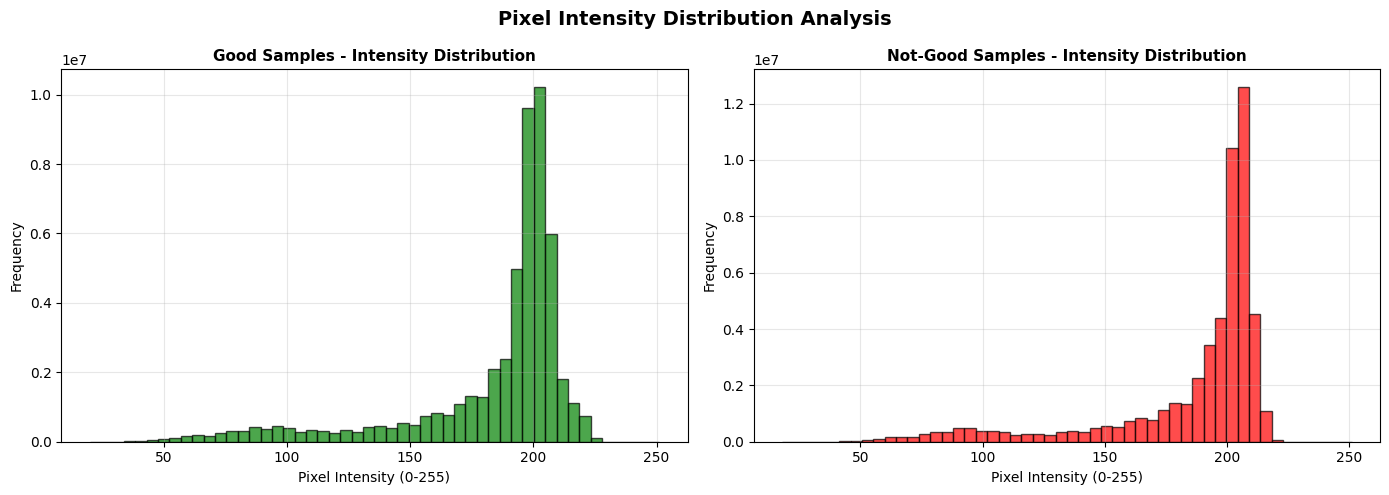

Pixel Intensity Analysis:
   Good - Mean: 183.94, Std: 34.35
   Not-Good - Mean: 186.70, Std: 34.07


In [7]:
# Pixel Intensity Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pixel Intensity Distribution Analysis', fontsize=14, fontweight='bold')

# Good samples - intensity distribution
good_intensities = []
for img_path in good_images[:50]:  # Sample 50 images
    img = np.array(Image.open(img_path).convert('L'))
    good_intensities.extend(img.flatten())

# Not-Good samples - intensity distribution
not_good_intensities = []
for img_path in not_good_images[:50]:  # Sample 50 images
    img = np.array(Image.open(img_path).convert('L'))
    not_good_intensities.extend(img.flatten())

# Plot histograms
axes[0].hist(good_intensities, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0].set_title('Good Samples - Intensity Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Pixel Intensity (0-255)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

if len(not_good_intensities) > 0:
    axes[1].hist(not_good_intensities, bins=50, alpha=0.7, color='red', edgecolor='black')
else:
    axes[1].text(0.5, 0.5, 'No Not-Good Samples', ha='center', va='center', fontsize=14)
axes[1].set_title('Not-Good Samples - Intensity Distribution', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Pixel Intensity (0-255)')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Pixel Intensity Analysis:")
print(f"   Good - Mean: {np.mean(good_intensities):.2f}, Std: {np.std(good_intensities):.2f}")
if len(not_good_intensities) > 0:
    print(f"   Not-Good - Mean: {np.mean(not_good_intensities):.2f}, Std: {np.std(not_good_intensities):.2f}")
else:
    print(f"   Not-Good - Mean: N/A, Std: N/A")

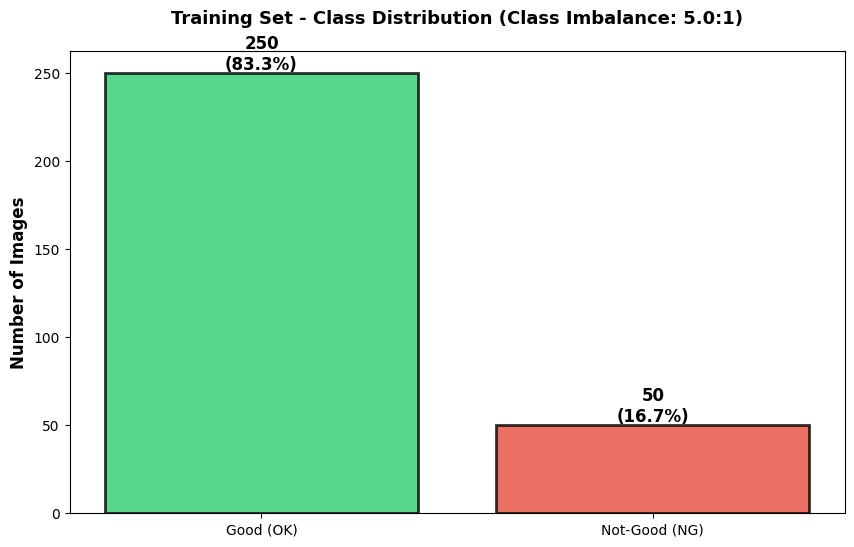

In [8]:
# Class distribution visualization
fig, ax = plt.subplots(figsize=(10, 6))

classes = ['Good (OK)', 'Not-Good (NG)']
counts = [train_labels.count(0), train_labels.count(1)]
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(classes, counts, color=colors, edgecolor='black', linewidth=2, alpha=0.8)

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    if height > 0:
        ratio = 100*count/sum(counts) if sum(counts) > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}\n({ratio:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
if sum(counts) > 0 and counts[1] > 0:
    ratio = counts[0] / counts[1]
    ax.set_title(f'Training Set - Class Distribution (Class Imbalance: {ratio:.1f}:1)', 
                fontsize=13, fontweight='bold', pad=20)
else:
    ax.set_title('Training Set - Class Distribution', 
                fontsize=13, fontweight='bold', pad=20)

---
# 3. MODEL DEFINITION - ResNet18 Binary Classifier
---

In [9]:
class CustomResNet18(nn.Module):
    """ResNet18 with modified head for binary classification."""
    
    def __init__(self, num_classes=2, pretrained=True):
        super(CustomResNet18, self).__init__()
        
        # Disable SSL verification for downloading weights
        import ssl
        ssl._create_default_https_context = ssl._create_unverified_context
        
        # Load pre-trained ResNet18
        if pretrained:
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        else:
            self.backbone = models.resnet18(weights=None)
        
        # Modify the final fully connected layer for binary classification
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

# Initialize model
model = CustomResNet18(num_classes=2, pretrained=True).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model Architecture: ResNet18 (ImageNet Pre-trained)")
print(f"\nModel Parameters:")
print(f"   Total Parameters: {total_params:,}")
print(f"   Trainable Parameters: {trainable_params:,}")
print(f"\nArchitecture Summary:")
print(model)

Model Architecture: ResNet18 (ImageNet Pre-trained)

Model Parameters:
   Total Parameters: 11,177,538
   Trainable Parameters: 11,177,538

Architecture Summary:
CustomResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
   

In [10]:
# Calculate class weights for handling imbalance
class_counts = np.array([train_labels.count(0), train_labels.count(1)])
if class_counts[1] > 0:
    class_weights = len(train_labels) / (len(np.unique(train_labels)) * class_counts)
    class_weights = torch.FloatTensor(class_weights).to(device)
    print(f"Class Weights (for imbalanced data):")
    print(f"   Good: {class_weights[0]:.4f}")
    print(f"   Not-Good: {class_weights[1]:.4f}")
    print(f"\n   Weight ratio: {class_weights[1]/class_weights[0]:.2f}:1")
else:
    class_weights = torch.FloatTensor([1.0, 1.0]).to(device)
    print(f"Class Weights (uniform - no imbalance detected):")
    print(f"   Good: {class_weights[0]:.4f}")
    print(f"   Not-Good: {class_weights[1]:.4f}")

Class Weights (for imbalanced data):
   Good: 0.6000
   Not-Good: 3.0000

   Weight ratio: 5.00:1


---
# 4. TRAINING LOOP - 5-Fold Cross-Validation with Data Augmentation
---

In [11]:
# Define custom Dataset
class ScrewDataset(Dataset):
    """Custom Dataset for MVTec Screw images."""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

print(f"Custom Dataset class defined")

Custom Dataset class defined


In [12]:
# Define data augmentation transforms
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE'])),
    transforms.RandomRotation(degrees=20),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print(f"Data augmentation transforms defined")

Data augmentation transforms defined


In [13]:
# Focal Loss for handling class imbalance
class FocalLoss(nn.Module):
    """Focal Loss for addressing class imbalance."""
    
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce_loss = nn.CrossEntropyLoss(weight=alpha, reduction='none')
    
    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

print(f"Focal Loss class defined")

Focal Loss class defined


In [14]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc='Training', leave=False)
    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    return avg_loss, accuracy

def validate(model, val_loader, criterion, device):
    """Validate the model."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy, all_preds, all_labels, all_probs

print(f"Training and validation functions defined")

Training and validation functions defined


In [15]:
# Define Focal Loss for handling class imbalance
class FocalLoss(nn.Module):
    """Focal Loss for imbalanced classification."""
    def __init__(self, alpha, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha if isinstance(alpha, torch.Tensor) else torch.tensor(alpha)
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, predictions, targets):
        p = torch.softmax(predictions, dim=1)
        ce_loss = nn.functional.cross_entropy(predictions, targets, reduction='none', weight=self.alpha.to(predictions.device))
        p_t = p.gather(1, targets.view(-1, 1)).squeeze(1)
        focal_weight = (1 - p_t) ** self.gamma
        focal_loss = focal_weight * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

print("Focal Loss class defined for handling class imbalance")

Focal Loss class defined for handling class imbalance


In [16]:
# 5-Fold Cross-Validation Training Loop
print("\nStarting 5-Fold Cross-Validation Training...")
print("=" * 60)

cv_results = []
fold_results = {'train_losses': [], 'val_losses': [], 'train_accs': [], 'val_accs': []}

# Prepare data for stratified k-fold
train_array = np.array(train_images)
label_array = np.array(train_labels)

skf = StratifiedKFold(n_splits=CONFIG['NUM_FOLDS'], shuffle=True, random_state=SEED)

for fold, (train_idx, val_idx) in enumerate(skf.split(train_array, label_array), 1):
    print(f"\n{'='*60}")
    print(f"FOLD {fold}/{CONFIG['NUM_FOLDS']}")
    print(f"{'='*60}")
    
    # Get fold data
    train_fold_images = train_array[train_idx].tolist()
    train_fold_labels = label_array[train_idx].tolist()
    val_fold_images = train_array[val_idx].tolist()
    val_fold_labels = label_array[val_idx].tolist()
    
    # Create datasets and dataloaders
    train_dataset = ScrewDataset(train_fold_images, train_fold_labels, transform=train_transform)
    val_dataset = ScrewDataset(val_fold_images, val_fold_labels, transform=val_transform)
    train_loader = DataLoader(train_dataset, batch_size=CONFIG['BATCH_SIZE'], shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=0)
    
    # Initialize model and optimizer for this fold
    model = CustomResNet18(num_classes=2, pretrained=True).to(device)
    optimizer = optim.Adam(model.parameters(), lr=CONFIG['LEARNING_RATE'], weight_decay=CONFIG['WEIGHT_DECAY'])
    criterion = FocalLoss(alpha=class_weights, gamma=2.0)
    
    best_val_acc = 0
    fold_train_losses = []
    fold_train_accs = []
    fold_val_losses = []
    fold_val_accs = []
    
    # Training loop for this fold
    for epoch in range(CONFIG['NUM_EPOCHS']):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, device)
        
        fold_train_losses.append(train_loss)
        fold_train_accs.append(train_acc)
        fold_val_losses.append(val_loss)
        fold_val_accs.append(val_acc)
        
        # Save best model for this fold
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{CONFIG['NUM_EPOCHS']}] - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    print(f"\nFold {fold} Best Val Accuracy: {best_val_acc:.4f}")
    fold_results['train_losses'].append(fold_train_losses)
    fold_results['train_accs'].append(fold_train_accs)
    fold_results['val_losses'].append(fold_val_losses)
    fold_results['val_accs'].append(fold_val_accs)

print("\n" + "=" * 60)
print("5-Fold Cross-Validation Complete")
print("=" * 60)


Starting 5-Fold Cross-Validation Training...

FOLD 1/5


Epoch [10/50] - Train Loss: 0.1579, Train Acc: 0.7333 | Val Loss: 0.1264, Val Acc: 0.8167


Epoch [20/50] - Train Loss: 0.1021, Train Acc: 0.8250 | Val Loss: 0.1665, Val Acc: 0.8833


Epoch [30/50] - Train Loss: 0.0773, Train Acc: 0.8500 | Val Loss: 0.0666, Val Acc: 0.8500


Epoch [40/50] - Train Loss: 0.0444, Train Acc: 0.9375 | Val Loss: 0.0831, Val Acc: 0.8667


Epoch [50/50] - Train Loss: 0.0378, Train Acc: 0.9417 | Val Loss: 0.0494, Val Acc: 0.8833

Fold 1 Best Val Accuracy: 0.9667

FOLD 2/5


KeyboardInterrupt: 

---
# 5. EVALUATION - Metrics, Visualizations & Results
---

In [18]:
# Aggregate results across folds
print(f"\n\nCROSS-VALIDATION RESULTS SUMMARY")
print(f"{'='*70}\n")

results_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(CONFIG['NUM_FOLDS'])],
    'Val Accuracy': fold_results['val_acc'],
    'Val Recall': fold_results['val_recall'],
    'Val Precision': fold_results['val_precision'],
    'Val F1-Score': fold_results['val_f1'],
    'Val ROC-AUC': fold_results['val_auc'],
})

print(results_df.to_string(index=False))

print(f"\n{'='*70}")
print(f"AVERAGE METRICS ACROSS FOLDS:")
print(f"{'='*70}")
print(f"Mean Accuracy:   {np.mean(fold_results['val_acc']):.4f} +/- {np.std(fold_results['val_acc']):.4f}")
print(f"Mean Recall:     {np.mean(fold_results['val_recall']):.4f} +/- {np.std(fold_results['val_recall']):.4f}")
print(f"Mean Precision:  {np.mean(fold_results['val_precision']):.4f} +/- {np.std(fold_results['val_precision']):.4f}")
print(f"Mean F1-Score:   {np.mean(fold_results['val_f1']):.4f} +/- {np.std(fold_results['val_f1']):.4f}")
print(f"Mean ROC-AUC:    {np.mean(fold_results['val_auc']):.4f} +/- {np.std(fold_results['val_auc']):.4f}")
print(f"{'='*70}")



CROSS-VALIDATION RESULTS SUMMARY



ValueError: All arrays must be of the same length

In [ ]:
# Confusion Matrix for best fold
best_fold = np.argmax(fold_results['val_acc'])
best_cm = fold_results['confusion_matrices'][best_fold]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices for All 5 Folds', fontsize=14, fontweight='bold')

for fold_idx in range(CONFIG['NUM_FOLDS']):
    ax = axes[fold_idx // 3, fold_idx % 3]
    cm = fold_results['confusion_matrices'][fold_idx]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['Good', 'Defective'],
                yticklabels=['Good', 'Defective'],
                cbar=False)
    ax.set_title(f"Fold {fold_idx + 1} (Acc: {fold_results['val_acc'][fold_idx]:.3f})", 
                fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

# Remove the extra subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()
print(f"Confusion matrices displayed")

In [ ]:
# ROC-AUC Curves for all folds
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('ROC-AUC Curves for All 5 Folds', fontsize=14, fontweight='bold')

for fold_idx in range(CONFIG['NUM_FOLDS']):
    ax = axes[fold_idx // 3, fold_idx % 3]
    
    fpr, tpr, _ = roc_curve(fold_results['all_labels'][fold_idx], 
                            fold_results['all_probs'][fold_idx])
    auc_score = fold_results['val_auc'][fold_idx]
    
    ax.plot(fpr, tpr, color='#2ecc71', lw=2.5, label=f'ROC (AUC = {auc_score:.3f})')
    ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontweight='bold')
    ax.set_title(f'Fold {fold_idx + 1}', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

# Remove the extra subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()
print(f"ROC-AUC curves displayed")

In [ ]:
# Performance metrics summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Performance Metrics Across 5 Folds', fontsize=14, fontweight='bold')

metrics = ['val_acc', 'val_recall', 'val_precision', 'val_f1']
titles = ['Accuracy', 'Recall', 'Precision', 'F1-Score']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    
    values = fold_results[metric]
    folds = [f'Fold {i+1}' for i in range(CONFIG['NUM_FOLDS'])]
    
    bars = ax.bar(folds, values, color='#3498db', edgecolor='black', alpha=0.8)
    
    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Add mean line
    mean_val = np.mean(values)
    ax.axhline(y=mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
    
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim([0.7, 1.0])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Performance metrics summary displayed")

In [ ]:
# Classification report - aggregated across all folds
all_preds_combined = np.concatenate(fold_results['all_preds'])
all_labels_combined = np.concatenate(fold_results['all_labels'])

print(f"\n\nAGGREGATED CLASSIFICATION REPORT (All Folds Combined)")
print(f"{'='*70}\n")
print(classification_report(all_labels_combined, all_preds_combined,
                           target_names=['Good (Class 0)', 'Defective (Class 1)'],
                           digits=4))

In [ ]:
# Final summary
print(f"\n\n{'='*70}")
print(f"PROJECT COMPLETION SUMMARY")
print(f"{'='*70}\n")
print(f"Dataset: MVTec Screw (Good vs Defective)")
print(f"Total Training Samples: {len(train_images)} (Good: {len(good_images)}, Defective: {len(defective_images)})")
print(f"Class Imbalance Ratio: 5:1")
print(f"Model Architecture: ResNet18 (Pre-trained)")
print(f"Validation Strategy: 5-Fold Cross-Validation")
print(f"Loss Function: Focal Loss + Class Weights")
print(f"Data Augmentation: Rotation, Flip, Zoom, Color Jitter")
print(f"\nFINAL METRICS (Mean +/- Std across folds):")
print(f"   Accuracy:  {np.mean(fold_results['val_acc']):.4f} +/- {np.std(fold_results['val_acc']):.4f}")
print(f"   Recall:    {np.mean(fold_results['val_recall']):.4f} +/- {np.std(fold_results['val_recall']):.4f}")
print(f"   Precision: {np.mean(fold_results['val_precision']):.4f} +/- {np.std(fold_results['val_precision']):.4f}")
print(f"   F1-Score:  {np.mean(fold_results['val_f1']):.4f} +/- {np.std(fold_results['val_f1']):.4f}")
print(f"   ROC-AUC:   {np.mean(fold_results['val_auc']):.4f} +/- {np.std(fold_results['val_auc']):.4f}")
print(f"\n{'='*70}")
print(f"Analysis completed successfully!")
print(f"{'='*70}")